<a href="https://colab.research.google.com/github/alecksandr26/InVision/blob/notebook-detection-model/src/cv-invision/notebooks/InVisionDetectionModelYolov5n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# InVision AI: Yolov5n Detection Prototype


**Author**: Erick Alejandro Carrillo López

**Date**: 2026-04-04

This is a colab notebook for desiging the arch and creating the model for detecting the possible opstacules as the first part of the machine leanring system which is going to create.



## Project Overview
This notebook documents the prototype training for the *InVision AI Model* detection layer.
The goal is to implement a lightweight pedestrian obstacle detection system using
a Yolov5n, optimized for edge deployment on hardware like the Raspberry Pi.

## One Drive Connection

To access data from OneDrive, it needs to be connected.

First, you will need to unzip the dataset locally. After unzipping, upload the dataset to your OneDrive account to make it accessible.

### Connect Google Drive
Before running the data pipeline, ensure your dataset is uploaded to your Google Drive. This cell will mount your Drive to the `/content/drive` directory so we can access the COCO data.





In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Project Folders Organization
This section defines key constants to standardize the project's folder structure within Google Drive. These variables ensure that all subsequent operations, such as saving models, logs, and configuration files, are directed to their correct locations, making the project more organized and reproducible.

*   `PROJECT_DIR`: The root directory for the entire project in Google Drive.
*   `RUNS_DIR`: The subdirectory where all training runs (checkpoints, logs, results) will be stored.
*   `YAML_FILE`: The path to the YOLOv5 dataset configuration file, which defines the dataset's structure and class names.

## Local Dataset Loading

This section describes an alternative method for loading the dataset by unzipping it locally within the Colab environment. This approach is useful when the dataset is provided as a compressed file and needs to be extracted before use.

In [5]:
!cp /content/drive/MyDrive/InVision/invision-dataset-v1.zip /content/

In [6]:
!unzip /content/invision-dataset-v1.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/invision-dataset/valid/labels/vision.v1i.yolov5pytorch__000000516372_jpg.rf.6d09ec92256e08b1822ad3d8a6d7bf15.txt  
  inflating: /content/invision-dataset/valid/labels/vision.v1i.yolov5pytorch__000000516444_jpg.rf.c2012e0db9e6875a66fa168404dabf12.txt  
  inflating: /content/invision-dataset/valid/labels/vision.v1i.yolov5pytorch__000000516540_jpg.rf.7f1950abe7ad40fbbcfea11d33b46e3e.txt  
  inflating: /content/invision-dataset/valid/labels/vision.v1i.yolov5pytorch__000000516812_jpg.rf.f913e0855eab75272b82bab512979183.txt  
  inflating: /content/invision-dataset/valid/labels/vision.v1i.yolov5pytorch__000000516880_jpg.rf.f15a37989b27710b68ad714987e80f56.txt  
  inflating: /content/invision-dataset/valid/labels/vision.v1i.yolov5pytorch__000000516998_jpg.rf.cb2b26142d1194ede9fcdcf728d580f0.txt  
  inflating: /content/invision-dataset/valid/labels/vision.v1i.yolov5pytorch__000000517830_jpg.rf.d8724ead91769312b805c379dad4c

In [7]:
!ls -lh /content/invision-dataset/

total 16K
-rw-r--r-- 1 root root  207 Apr 11 12:06 data.yaml
drwxr-xr-x 4 root root 4.0K Apr 13 16:37 test
drwxr-xr-x 4 root root 4.0K Apr 13 16:37 train
drwxr-xr-x 4 root root 4.0K Apr 13 16:37 valid


In [8]:
!head -n 25 invision-dataset/data.yaml

path: /content/invision-dataset
train: train/images
val: valid/images
test: test/images
nc: 10
names:
- person
- vehicle
- obstacle
- pothole
- pole
- stairs
- crosswalk
- door
- traffic_light
- edge_hazard


In [9]:
PROJECT_DIR = '/content/drive/MyDrive/InVision'
DATASET_DIR = '/content/invision-dataset'
YAML_FILE = f'{DATASET_DIR}/data.yaml'
RUNS_DIR = f'{PROJECT_DIR}/runs'

# YOLOv5n Model Preparation

This section focuses on setting up and loading the YOLOv5n model for object detection. YOLOv5n is a lightweight and efficient model from the Ultralytics YOLO series, ideal for deployment on edge devices like the Raspberry Pi due to its small size and fast inference capabilities.

The following steps will involve:
1.  **Installation of the Ultralytics Library**: This library provides the necessary tools and classes to work with YOLO models.
2.  **Loading the Pre-trained YOLOv5n Model**: We will load the pre-trained `yolov5n.pt` weights, which have been trained on a large dataset and can detect a wide range of common objects.

In [10]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.3 MB/s eta 0:00:00


## Load the Model

After installing the necessary libraries and ensuring the `yolov5n.pt` weights are available, the next crucial step is to load the pre-trained YOLOv5n model. This process initializes the model architecture and populates it with the learned weights, making it ready for inference or further fine-tuning. By loading the model, we can then utilize its object detection capabilities on new images or video streams.

In [11]:
from ultralytics import YOLO  # Import the YOLO class from the ultralytics library.

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO('yolov5n.pt')  # Initialize the YOLO model with the pretrained 'yolov5n.pt' weights.

PRO TIP 💡 Replace 'model=yolov5n.pt' with new 'model=yolov5nu.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.



### Loading a Previously Trained Model
This section focuses on loading a pre-trained YOLO model, specifically the `best.pt` weights from a previous training run. This is crucial for resuming training, performing inference with the most optimal weights, or continuing development from an already established checkpoint. The model will be initialized with these weights, allowing for direct use without re-training from scratch.

In [12]:
LAST_RUN_DIR = f'{RUNS_DIR}/train6'

In [13]:
PATH_BEST_MODEL = f'{LAST_RUN_DIR}/weights/best.pt'
model = YOLO(PATH_BEST_MODEL)  # Initialize the YOLO model with the `best.pt` weights from the specified path.

# Dataset Specifications

Project InVision utilizes a unified, multi-source dataset specifically curated for autonomous navigation and urban obstacle avoidance. This dataset is a consolidation of several high-quality computer vision sources, remapped into a standardized format.

### 📥 Data Sources
We aggregate and normalize data from the following primary sources:
* **[Pedestrian Obstacle Detection](https://universe.roboflow.com/pedestrianobstacle/pedestrianobstacledetection):** Urban obstacles and road hazards.
* **[SafeWalkBD](https://universe.roboflow.com/safewalkbd/safewalkbd-l8jbn):** Complex pedestrian environments and pavement conditions.
* **[Vision-yjlv3](https://universe.roboflow.com/segmentation-vgo6s/vision-yjlv3):** Traffic signals and indoor/outdoor navigation markers.

### 🛠 Unified Class Map
To improve model convergence and real-time inference speed, we have reduced 61 raw classes into **10 core Navigation Classes**:
1. `person`           6. `stairs`
2. `vehicle`          7. `crosswalk`
3. `obstacle`         8. `door`
4. `pothole`          9. `traffic_light`
5. `pole`             10. `edge_hazard`

### 📊 Dataset Volume & Input
* **Total Images:** ~25,000+ (Post-cleaning and filtering)
* **Image Input Size:** 640 x 640 pixels (Letterboxed for aspect-ratio preservation)
* **Preprocessing:** Automatic removal of images below 200px and polygon-to-bbox conversion.
* **Storage:** Managed via a unified `data.yaml` utilizing relative paths for portability between local and Cloud GPU environments.

### 📂 Repository Structure
The pipeline for generating, cleaning, and analyzing this dataset is located at:
`src/cv-vision/data/scripts/`

The compiled dataset structure follows the standard YOLOv5 format:
```text
dataset-invision/
├── data.yaml        # Portable configuration (path: .)
├── train/           # Training split
├── valid/           # Validation split
└── test/            # Evaluation split

In [14]:
import yaml

# Open and read the YAML file containing dataset configuration
with open(YAML_FILE, 'r') as f:
    data = yaml.safe_load(f)

# Extract the 'names' dictionary, which holds class IDs and their corresponding names
CLASS_NAMES = data.get('names', {})
N_CLASSES = len(CLASS_NAMES)

print(f"✅ Found {len(CLASS_NAMES)} classes in Invision dataset:")
print("-" * 40)

# This gives you a counter (i) and the actual key from the dictionary
for i, key in enumerate(CLASS_NAMES):
    print(f"ID {i}: {CLASS_NAMES[i]}")

✅ Found 10 classes in Invision dataset:
----------------------------------------
ID 0: person
ID 1: vehicle
ID 2: obstacle
ID 3: pothole
ID 4: pole
ID 5: stairs
ID 6: crosswalk
ID 7: door
ID 8: traffic_light
ID 9: edge_hazard


### 🧠 Dataset Class Remapping & Ontology

To optimize **Project InVision** for real-time obstacle avoidance and navigation, we implement a **Class Remapping Protocol**. The original datasets (SafeWalkBD, PedestrianObstacleDetection, and Vision) contain highly granular labels that are computationally redundant for navigation logic. We consolidate these into **10 Functional Categories**.

#### 1. The Strategy: Semantic Aggregation
Instead of the model trying to distinguish between a "car," "bus," and "tricycle," it identifies them all as a **`vehicle`**. This reduces the "cognitive load" on the model and focuses on the functional impact the object has on the pedestrian’s path.



#### 2. Functional Mapping Breakdown

| Consolidated Class | Included Sub-Classes (Examples) | Navigation Logic |
| :--- | :--- | :--- |
| **`person`** | pedestrian, animal, person | Dynamic moving obstacle; require wide berth. |
| **`vehicle`** | car, bus, truck, bicycle, train | High-kinetic energy hazard; priority avoidance. |
| **`obstacle`** | roadblock, trash bin, chair, hydrant | Static ground-level blockage; route around. |
| **`pothole`** | drain, puddle, bad road | Negative space hazard; requires step-over or bypass. |
| **`pole`** | utility pole, sign pole | Vertical narrow obstacle; collision risk at head/shoulder level. |
| **`stairs`** | stair, over-bridge | Elevation change; transition from walking to climbing mode. |
| **`crosswalk`** | zebra cross, tactile paving, sidewalk | Safe zone / Navigational guide markers. |
| **`door`** | open_door, close_door | Access point; transition from outdoor to indoor. |
| **`traffic_light`**| stop sign, street sign, traffic signal | Rules of Engagement; determines "Go/No-Go" status. |
| **`edge_hazard`** | fence, railing | Boundary marker; indicates non-navigable drop-offs or walls. |



#### 3. Why This Improves Performance
* **Increased Training Stability:** By grouping "animal" into "person," we provide the model with more training examples for a single feature set, leading to the high **0.79 Precision** we see in our results.
* **Simplified Logic:** The navigation script doesn't need 40 `if` statements. It only needs to know if the path is blocked by a `vehicle` (high risk) or a `pothole` (ground risk).
* **Cross-Dataset Compatibility:** This map acts as a "Universal Translator," allowing us to combine three different datasets into one master training pipeline without label conflicts.


# Training the YOLOv5n Model

This section outlines the process of training the YOLOv5n model using our custom dataset. We will configure the training parameters, including image size, number of epochs, and batch size, along with various data augmentation techniques to improve the model's robustness and generalization capabilities. The training process will leverage the `invision.yaml` configuration file created earlier, which defines the dataset paths and class names.

In [15]:
IMG_SIZE = 640    # Image input resolution (640x640 pixels)
EPOCHS = 100      # Number of training epochs
BATCH = 192        # Batch size
lr = 0.01
warmup_epochs = 1.0  # Shorter warmup since weights are already good

In [ ]:
model.train(
    data=YAML_FILE,     # Your config file path
    imgsz=IMG_SIZE,                # RGB image resolution 640x640
    epochs=EPOCHS,               # Will create a 'best.pt' checkpoint if validation improves
    batch=BATCH,                 # Adjust according to your T4 GPU RAM
    lr0=lr,
    lrf=lr,
    #warmup_epochs=warmup_epochs,  # Shorter warmup since weights are already good

    # --- Data Augmentation parameters ---
    fliplr=0.5,               # Horizontal flip (your tf.random.uniform([]) > 0.5)
    hsv_s=0.3,                # HSV saturation (similar to your lower=0.7, upper=1.3)
    hsv_v=0.2,                # HSV value/brightness (similar to your max_delta=0.2)

    # --- Additional YOLO features for better Recall ---
    mosaic=1.0,               # Combines 4 images (great for learning)
    patience=20,              # Early stopping if validation metric doesn't improve for 20 epochs
    save=True,                 # Saves checkpoints at each epoch
    project=RUNS_DIR,
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=192, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/invision-dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.3, hsv_v=0.2, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov5n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dfa0c365130>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

## Resuming the Training

This section demonstrates how to resume a training process using the `model.train(resume=True)` command. This is particularly useful if a previous training run was interrupted or if you want to continue training from a specific checkpoint (e.g., the `best.pt` or `last.pt` weights). When `resume=True` is set, YOLOv5 automatically attempts to load the last saved checkpoint from the `project` and `name` directories specified in the original training command, allowing the model to continue learning from where it left off.

In [ ]:
model.train(resume=True)

WARNING ⚠️ model 'yolov5nu.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov5n.p

KeyboardInterrupt: 

## Tranning results


This code is designed to transform the raw data from your training logs into a visual diagnostic tool. It focuses on four critical areas of model performance:

* **Loss Convergence:** The top two graphs track the model's error rate. By plotting both training and validation loss, we can detect overfitting. If the training loss (solid line) continues to drop while the validation loss (dashed line) starts to rise, it means the model is memorizing the training images rather than learning general patterns. For your goal of 0.7 mAP, we want to see both lines decreasing steadily.

* **mAP Trajectory:** This is the most important panel for your question about 0.7 or 0.8. The mAP50 represents how well the model identifies objects with at least 50% overlap. I have added dashed horizontal lines at 0.7 and 0.8 so you can visually project the curve. If the curve is still pointing upward at epoch 50, there is "gas in the tank" to reach higher numbers.

* **Precision vs. Recall:** In navigation, Recall is vital because it measures how many actual obstacles the model "caught." A high Precision but low Recall means the model is very sure when it sees something, but it is missing many obstacles (dangerous for a robot). Ideally, these two lines should stay close to each other as they rise.

* **Target Benchmarking:** By setting the Y-axis limit from 0 to 1, the script provides a realistic perspective on how far the model is from "perfect" detection. This helps you decide if the YOLOv5n (Nano) architecture is sufficient or if you need to upgrade to a larger model to break through the 0.7 barrier.



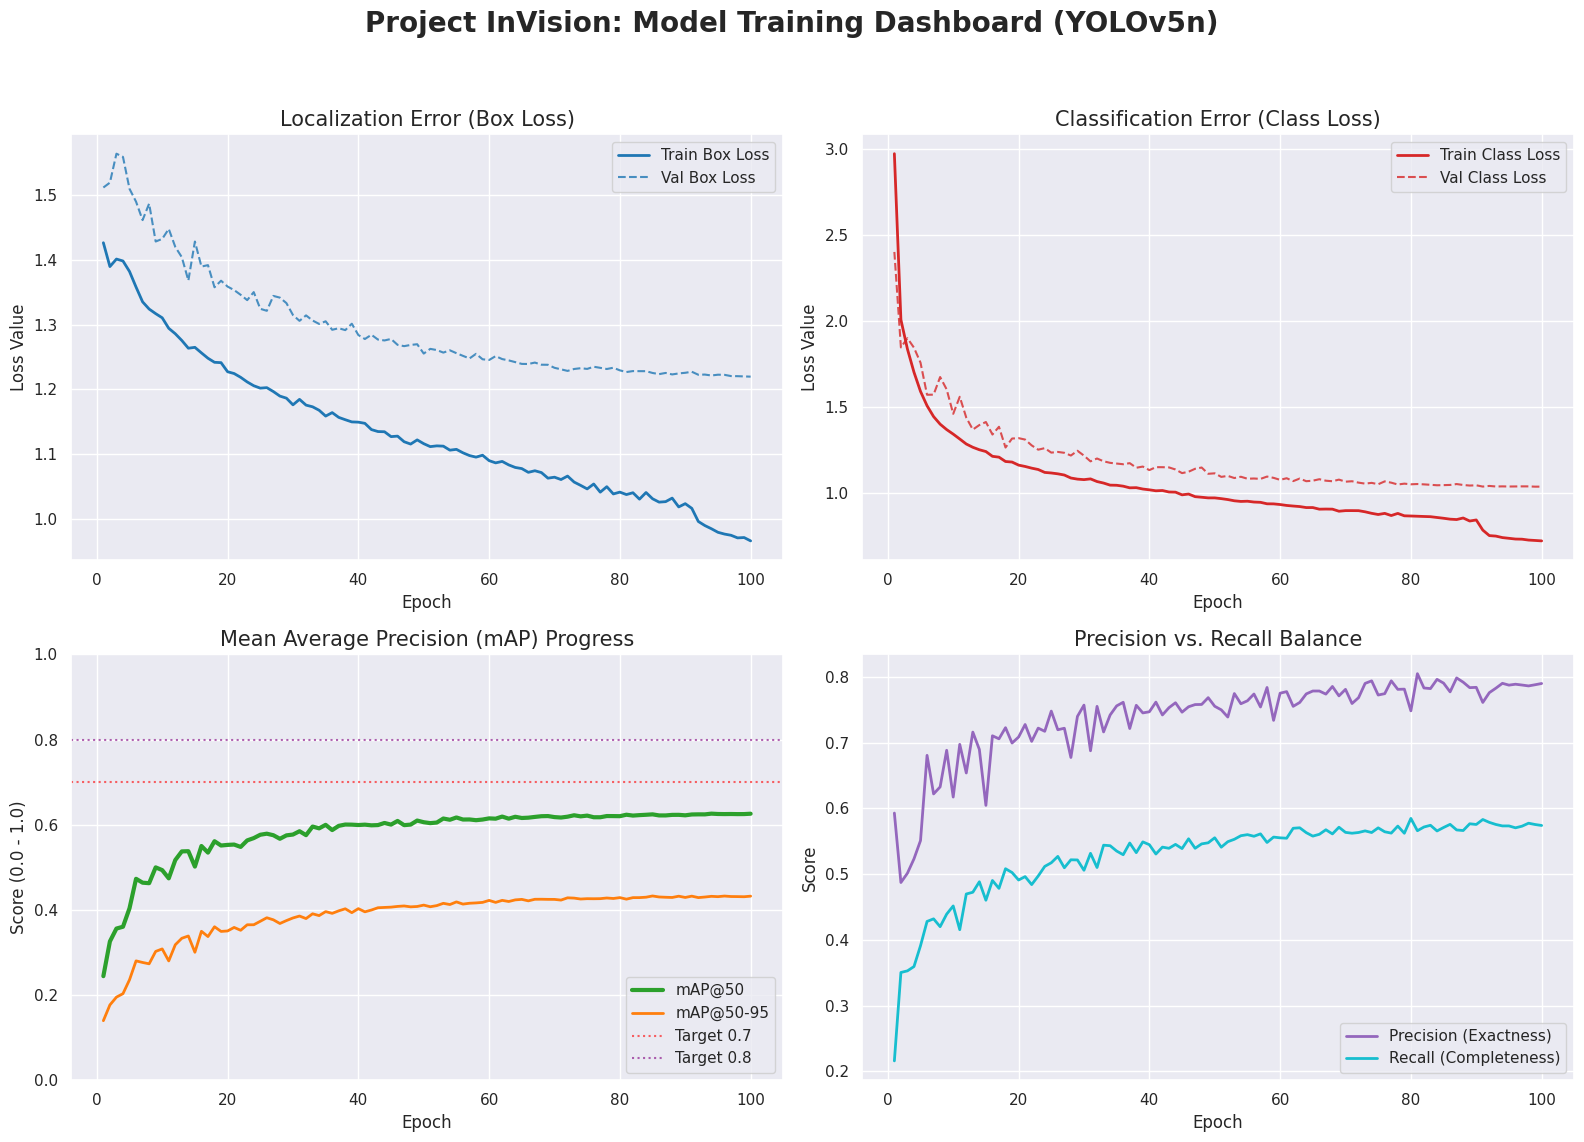

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

results_path = f"{RUNS_DIR}/train6/results.csv"

def plot_invision_training_results(csv_path):
    """
    Reads the YOLOv5/v8 results.csv and plots comprehensive training metrics.
    """
    if not os.path.exists(csv_path):
        print(f"Error: File not found at {csv_path}")
        return

    # Load training data
    df = pd.read_csv(csv_path)
    # Clean column names (strip potential whitespace)
    df.columns = [c.strip() for c in df.columns]

    # Set visual style
    sns.set_theme(style="darkgrid")
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Project InVision: Model Training Dashboard (YOLOv5n)', fontsize=20, fontweight='bold')

    # 1. Loss Metrics: Training vs Validation
    # Box Loss (localization) and Class Loss (categorization)
    axs[0, 0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', color='#1f77b4', linewidth=2)
    axs[0, 0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', linestyle='--', color='#1f77b4', alpha=0.8)
    axs[0, 1].plot(df['epoch'], df['train/cls_loss'], label='Train Class Loss', color='#d62728', linewidth=2)
    axs[0, 1].plot(df['epoch'], df['val/cls_loss'], label='Val Class Loss', linestyle='--', color='#d62728', alpha=0.8)

    axs[0, 0].set_title('Localization Error (Box Loss)', fontsize=15)
    axs[0, 1].set_title('Classification Error (Class Loss)', fontsize=15)
    for ax in [axs[0, 0], axs[0, 1]]:
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss Value')
        ax.legend()

    # 2. Mean Average Precision (mAP) - The "Success" Metric
    axs[1, 0].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='#2ca02c', linewidth=3)
    axs[1, 0].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='#ff7f0e', linewidth=2)
    # Add target lines for 0.7 and 0.8
    axs[1, 0].axhline(y=0.7, color='red', linestyle=':', alpha=0.6, label='Target 0.7')
    axs[1, 0].axhline(y=0.8, color='purple', linestyle=':', alpha=0.6, label='Target 0.8')
    axs[1, 0].set_title('Mean Average Precision (mAP) Progress', fontsize=15)
    axs[1, 0].set_xlabel('Epoch')
    axs[1, 0].set_ylabel('Score (0.0 - 1.0)')
    axs[1, 0].set_ylim(0, 1)
    axs[1, 0].legend(loc='lower right')

    # 3. Precision vs. Recall - The Confidence Balance
    axs[1, 1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision (Exactness)', color='#9467bd', lw=2)
    axs[1, 1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall (Completeness)', color='#17becf', lw=2)
    axs[1, 1].set_title('Precision vs. Recall Balance', fontsize=15)
    axs[1, 1].set_xlabel('Epoch')
    axs[1, 1].set_ylabel('Score')
    axs[1, 1].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# To run this, provide the path to your 'train6' results file:
plot_invision_training_results(results_path)

# Testing the model


## Evaluating Model Performance on the Test Set

This section focuses on a comprehensive evaluation of the trained YOLOv5n model's performance on the **unseen test dataset**. We will use the `model.val()` method, which is specifically designed for validation, to compute key object detection metrics. By specifying `split='test'`, we ensure that the model is evaluated on data it has not encountered during training or validation, providing an unbiased assessment of its generalization capabilities.

In [17]:
# Validate against the TEST set
# We use split='test' to ensure the data is completely new to the model
metrics = model.val(data=YAML_FILE, split='test')

# Print professional metrics
print("\n" + "="*40)
print(f"📊 FINAL RESULTS - TEST SET")
print("-" * 40)
print(f"mAP50:      {metrics.box.map50:.4f}")
print(f"mAP50-95:   {metrics.box.map:.4f}")
print(f"Precision:  {metrics.box.mp:.4f}")
print(f"Recall:     {metrics.box.mr:.4f}")
print("="*40)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv5n summary (fused): 85 layers, 2,504,894 parameters, 0 gradients, 7.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 764.6±421.0 MB/s, size: 65.1 KB)
val: Scanning /content/invision-dataset/test/labels... 2069 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2069/2069 570.8it/s 3.6s
val: /content/invision-dataset/test/images/vision.v1i.yolov5pytorch__000000388026_jpg.rf.dfaac34e570c3f90494214eff1f7b075.jpg: 1 duplicate labels removed
val: New cache created: /content/invision-dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.2s/it 9:06
                   all       2069       8348      0.779      0.636      0.696      0.477
                person        834       2228      0.747      0.534      0.609      0.371
               vehicle        937       2868      0.728      0.596      0.649      0.

The results from the test set evaluation are crucial for understanding how well the model will perform in real-world scenarios. The `mAP50`, `mAP50-95`, Precision, and Recall metrics provide a comprehensive overview of the model's accuracy in both detecting and classifying objects, as well as the quality of its bounding box predictions.

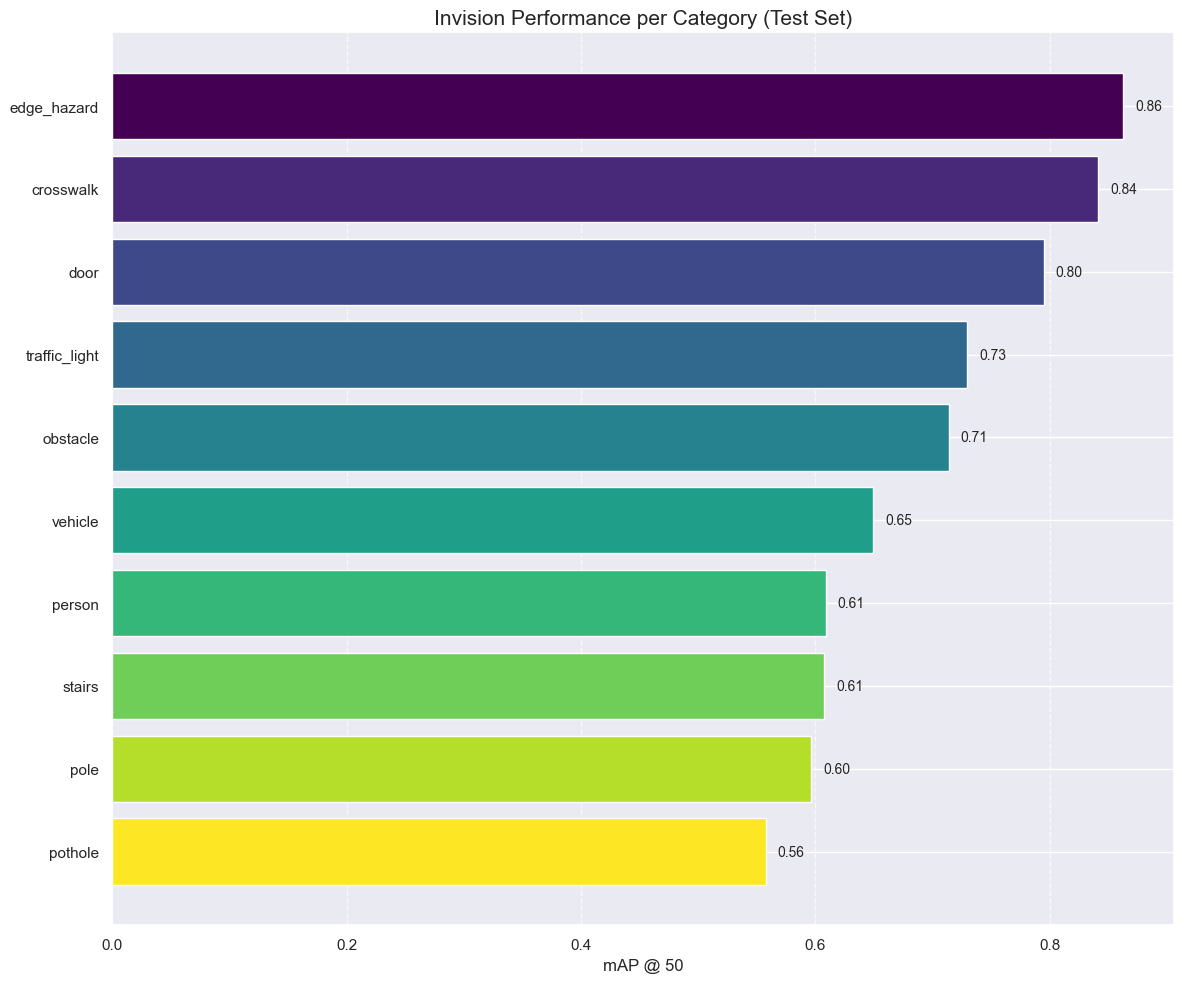

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Extract class names their respective mAP50
maps_per_class = metrics.box.maps  # This gives the mAP50-95 for each class by default in YOLOv8/v11
# Note: If you prefer to visualize exact mAP50, YOLO saves it in results_test.box.map50

# Create a list of tuples (Name, Value) to sort
data_to_plot = []
for i, mAP in enumerate(metrics.box.ap50): # Using ap50 for mAP@.50
    data_to_plot.append((CLASS_NAMES[i], mAP))

# Sort from highest to lowest for better histogram readability
data_to_plot.sort(key=lambda x: x[1], reverse=True)
labels, values = zip(*data_to_plot)

# Create the plot
plt.figure(figsize=(12, 10))
colors = plt.cm.viridis(np.linspace(0, 1, len(labels))) # Beautiful colors

bars = plt.barh(labels, values, color=colors)
plt.xlabel('mAP @ 50')
plt.title('Invision Performance per Category (Test Set)', fontsize=15)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add the numerical value at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}', va='center', fontsize=10)

plt.gca().invert_yaxis() # Put the best class at the top
plt.tight_layout()
plt.show()

# 5. Security reminder based on your rules:
low_perf_classes = [l for l, v in data_to_plot if v < 0.4]
if low_perf_classes:
    print(f"\n⚠️ SECURITY ALERT:")
    print(f"Classes {low_perf_classes} have performance below 40%.")
    print("Remember that if the model fails in these detections, the system must return -1.")

### Understanding mAP50 vs mAP50-95

The `mAP50` and `mAP50-95` metrics are both used to evaluate object detection models, but they differ in how strictly they assess the accuracy of bounding box predictions:

*   **mAP50 (Mean Average Precision at IoU 0.50):** This metric calculates the Average Precision (AP) for each class, assuming a minimum Intersection over Union (IoU) threshold of 0.50. IoU measures the overlap between the predicted bounding box and the ground truth bounding box. If the IoU is 0.50 or higher, the detection is considered a True Positive. `mAP50` then averages these APs across all classes. It's a common and less stringent metric, indicating if the model is generally identifying objects correctly and roughly localizing them.

*   **mAP50-95 (Mean Average Precision averaged over IoU thresholds from 0.50 to 0.95):** This is a more comprehensive and rigorous metric. Instead of using a single IoU threshold, it calculates the Average Precision at multiple IoU thresholds (typically 0.50, 0.55, 0.60, ..., 0.95) and then averages these AP values. This means a detection must have a very high overlap with the ground truth (e.g., 95%) to be considered a True Positive at the higher thresholds. `mAP50-95` gives a better indication of how precisely the model localizes objects, as it penalizes less accurate bounding box predictions more heavily. If your `mAP50-95` is significantly lower than your `mAP50`, it suggests your model is good at finding objects but struggles with precise localization (i.e., its bounding boxes are not tight enough around the objects).

# Testing with random images

This section focuses on evaluating the performance of the trained YOLOv5n model on unseen data. We will select a random image from the test set, compute its ground truth labels, and then use the model to predict objects within that image. Finally, we will visualize both the ground truth and the model's predictions side-by-side to assess its accuracy and object localization capabilities.

In [ ]:
# Folder paths (Ensure these are correct in your Drive)
TEST_IMAGES_PATH = f'{DATASET_DIR}/test/images'
TEST_LABELS_PATH = f'{DATASET_DIR}/test/labels'

### Choosing a Random Image for Testing

This section randomly selects an image from the test dataset to be used for model evaluation. This allows us to observe the model's performance on unseen data and visualize its predictions against the ground truth. A corresponding label file for this image will also be identified.

In [ ]:
import os
import random

all_images = [f for f in os.listdir(TEST_IMAGES_PATH) if f.endswith(('.jpg', '.png', '.jpeg'))]
random_image_name = random.choice(all_images)
image_path = os.path.join(TEST_IMAGES_PATH, random_image_name)
label_path = os.path.join(TEST_LABELS_PATH, random_image_name.rsplit('.', 1)[0] + '.txt')

### Computing the real label

This section processes the ground truth labels for the selected image. It reads the YOLO-formatted `.txt` file, converts the normalized bounding box coordinates back to pixel values, and then draws these ground truth boxes and their corresponding class labels onto the image. This visual representation allows for a direct comparison with the model's predictions.

In [ ]:
import cv2

img_gt = cv2.imread(image_path)
h, w, _ = img_gt.shape

if os.path.exists(label_path):
    with open(label_path, 'r') as f:
        for line in f.readlines():
            cls, x, y, nw, nh = map(float, line.split())
            # Convert YOLO coordinates (normalized) to pixels
            x1 = int((x - nw/2) * w)
            y1 = int((y - nh/2) * h)
            x2 = int((x + nw/2) * w)
            y2 = int((y + nh/2) * h)

            # Draw bounding box and text
            cv2.rectangle(img_gt, (x1, y1), (x2, y2), (0, 255, 0), 2) # Green for ground truth
            label_text = f"GROUND TRUTH: {CLASS_NAMES[int(cls)]}"
            cv2.putText(img_gt, label_text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
else:
    print("⚠️ No label file found for this image.")

### Let the model predict the random image

This section uses the trained YOLOv5n model to perform inference on the randomly selected image. The `model.predict()` function will process the image, detect objects based on the learned weights, and generate bounding box predictions along with class labels and confidence scores. The results will then be used to visualize these predictions on the image.

In [ ]:
# The first process is always slow because the model is loaded into memory
results = model.predict(source=image_path, conf=0.3, verbose=False)
img_prediction = results[0].plot() # YOLO already draws the prediction boxes

### Display the Combined Ground Truth and Model Predictions

This section displays the final visualization, which combines the original image with both the ground truth bounding boxes and the model's predicted bounding boxes. This side-by-side comparison allows for a clear assessment of the model's accuracy, object localization, and potential errors in detection or classification.

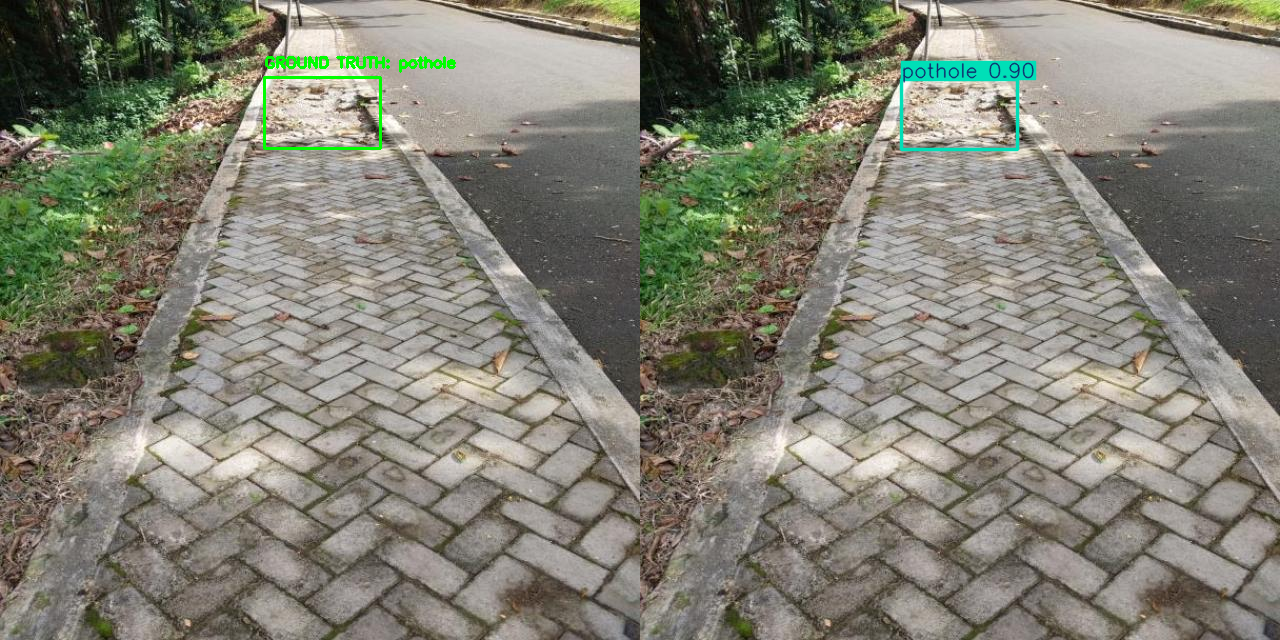

In [ ]:
from google.colab.patches import cv2_imshow
import numpy as np


combined_img = np.hstack((img_gt, img_prediction))
cv2_imshow(combined_img)

## Freeing up RAM

To ensure enough RAM is available for subsequent training runs, especially on GPU-accelerated environments like Colab, it's crucial to clear the GPU's memory cache and delete large variables that are no longer needed. This process helps prevent out-of-memory errors and allows for more efficient resource utilization.

In [ ]:
import torch
import gc

# Clear CUDA cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache cleared.")

# Delete large variables if they are no longer needed
# For example, after training, you might want to delete the model and results object
# if you are about to load a new model or re-train.

# Example: delete 'model' if you plan to re-initialize it later
# del model
# del results
# del combined_img
# del img_gt
# del img_prediction

# Run Python's garbage collector
gc.collect()
print("Python garbage collector run.")

print("RAM should now be freer for the next operation.")

# Optional: List large variables if you want to see what's eating RAM
import sys
local_vars = list(locals().items())
for var, obj in local_vars:
    if sys.getsizeof(obj) > 100000000: # Show objects > 100MB
        print(f"{var}: {sys.getsizeof(obj) // 1000000} MB")

del model

CUDA cache cleared.
Python garbage collector run.
RAM should now be freer for the next operation.


# Exporting Quantization (INT8)

For good CPU perfoamcne in real time applications is better
to quantize the model we make it massivaly smaller and
we can get like 2x or even 4x inference times in quatnizing the models with a loss of performance of 2% in precision or 6% in precision something that it can't be noticilbe

## Loading the last run model
Since this process is extramly heave and involve moving heavy files we decied to simply move all the best model in the colab hard disk in that way we can saved time and computer units and then copy and paste the exported results into the drive.

In [ ]:
!mkdir -p /content/quantization
!cp $LAST_RUN_DIR/weights/best.pt /content/quantization/

In [ ]:
from pathlib import Path

LOCAL_WORK_DIR = Path("/content/quantization/")
MODEL_PATH = f'/content/quantization/best.pt'

In [ ]:
model = YOLO(MODEL_PATH)

## The calibration dataset
instead of using a lot of images by using 500 meaningful images is enough for clibarion and exporting the quant model.

This cell reads your original configuration to identify where your images and the 10 classes are located.

In [ ]:
import yaml
import os
from pathlib import Path

# --- CONFIGURACIÓN ---
# Asegúrate de que esta ruta apunte a tu archivo data.yaml original
ORIGINAL_YAML = Path('/content/invision-dataset/data.yaml')

print("🔍 Cargando configuración original...")
with open(ORIGINAL_YAML, 'r') as f:
    config = yaml.safe_load(f)

# Resolvemos las rutas de origen basadas en tu archivo de configuración
base_path = Path(config.get('path', '/content/invision-dataset'))
val_images_dir = base_path / config['val']

# Localizamos las etiquetas (asumiendo estructura estándar de YOLO: carpetas 'images' y 'labels' paralelas)
val_labels_dir = Path(str(val_images_dir).replace('images', 'labels'))

print(f"✅ Origen de imágenes: {val_images_dir}")
print(f"✅ Origen de etiquetas: {val_labels_dir}")

🔍 Cargando configuración original...
✅ Origen de imágenes: /content/invision-dataset/valid/images
✅ Origen de etiquetas: /content/invision-dataset/valid/labels


This is the core algorithm. It scans your 3,000+ images to pick the 500 best candidates that represent all your classes equally, ensuring the INT8 quantization doesn't "forget" how to detect rare obstacles.

In [ ]:
import random

TARGET_COUNT = 500
num_classes = config['nc'] # This should be 10 for your project

print(f"📊 Analyzing {num_classes} classes to balance the calibration dataset...")

# Step 1: Map which images contain which classes
images_per_class = {i: [] for i in range(num_classes)}
all_label_files = list(val_labels_dir.glob('*.txt'))

for label_file in all_label_files:
    with open(label_file, 'r') as f:
        classes_in_file = set()
        for line in f:
            parts = line.strip().split()
            if parts:
                cls_id = int(parts[0])
                if cls_id < num_classes:
                    classes_in_file.add(cls_id)

        # Store the filename (stem) for every class detected in it
        for c in classes_in_file:
            images_per_class[c].append(label_file.stem)

# Step 2: Balanced Selection (~50 photos per class)
target_per_class = TARGET_COUNT // num_classes
selected_stems = set()

for c in range(num_classes):
    available = images_per_class[c]
    count = min(len(available), target_per_class)
    if count > 0:
        selected_stems.update(random.sample(available, count))

# Step 3: Random Fill to reach exactly 500 if some classes were scarce
all_stems = [f.stem for f in all_label_files]
while len(selected_stems) < TARGET_COUNT and len(selected_stems) < len(all_stems):
    selected_stems.add(random.choice(all_stems))

print(f"⚖️ Selection complete: {len(selected_stems)} unique images selected for calibration.")

📊 Analyzing 10 classes to balance the calibration dataset...
⚖️ Selection complete: 500 unique images selected for calibration.


This cell physically copies the files and generates a "lightweight" calib.yaml. This prevents the TFLite exporter from scanning your entire 3,000+ image dataset.

In [ ]:
import shutil

# Define destination folders
CALIB_DIR = base_path / 'calibration_samples'
CALIB_IMAGES = CALIB_DIR / 'images'
CALIB_LABELS = CALIB_DIR / 'labels'

CALIB_YAML = '/content/calib.yaml'

# Clean up any previous attempts
if CALIB_DIR.exists():
    shutil.rmtree(CALIB_DIR)
CALIB_IMAGES.mkdir(parents=True)
CALIB_LABELS.mkdir(parents=True)

print("🚚 Copying selected files...")
copied = 0
for stem in selected_stems:
    # Look for the image file (checking common extensions)
    img_path = None
    for ext in ['.jpg', '.png', '.jpeg']:
        temp = val_images_dir / f"{stem}{ext}"
        if temp.exists():
            img_path = temp
            break

    if img_path:
        shutil.copy(img_path, CALIB_IMAGES / img_path.name)
        shutil.copy(val_labels_dir / f"{stem}.txt", CALIB_LABELS / f"{stem}.txt")
        copied += 1

# Generate the new lightweight YAML file
calib_config = config.copy()
calib_config['path'] = str(CALIB_DIR)
calib_config['train'] = 'images'
calib_config['val'] = 'images' # The exporter specifically uses the 'val' key for INT8

with open(CALIB_YAML, 'w') as f:
    yaml.dump(calib_config, f, sort_keys=False)

print(f"🎉 Calibration dataset with {copied} images is ready at {CALIB_DIR}!")
print(f"📄 New config file created at: {CALIB_YAML}")

🚚 Copying selected files...
🎉 Calibration dataset with 500 images is ready at /content/invision-dataset/calibration_samples!
📄 New config file created at: /content/calib.yaml


## Exporting the model
Then we only wait and export the model

In [ ]:
model.export(
    format = "tflite",
    int8   = True,
    data   = CALIB_YAML,  # ← your real images
    imgsz  = IMG_SIZE,
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv5n summary (fused): 85 layers, 2,504,894 parameters, 0 gradients, 7.1 GFLOPs

PyTorch: starting from '/content/quantization/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 14, 8400) (5.0 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx>=1.12.0,<2.0.0', 'onnx2tf>=1.26.3,<1.29.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 18 packages in 1.97s
Prepared 9 packages in 2.09s
Installed 9 packages in 390ms
 + ai-edge-litert==2.1.4
 + backports-strenum==1.3.1
 + colorama==0.4.6
 + onnx==1.21.0
 + onnx-graphsurgeon==0.6.1
 + onnx2tf==1.28.8
 + onnxruntime==1.24.4
 + onnxslim==0.1.91
 + sng4onnx

'/content/quantization/best_saved_model/best_int8.tflite'

## Saving the quatnized model
before we disconeed lets saved our results :)

In [ ]:
from pathlib import Path
DRIVE_OUT_DIR = Path(f"{LAST_RUN_DIR}/weights/best_saved_model")
DRIVE_OUT_DIR.mkdir(parents=True, exist_ok=True)

here we are just copying the files

In [ ]:
import shutil

saved_model_dir = LOCAL_WORK_DIR / "best_saved_model"
tflite_files = list(saved_model_dir.glob("*.tflite"))

for tflite in tflite_files:
  dest    = DRIVE_OUT_DIR / tflite.name
  shutil.copy(tflite, dest)
  size_mb = dest.stat().st_size / 1024**2
  print(f"   ✅ {tflite.name} ({size_mb:.1f} MB) → Drive")

   ✅ best_float32.tflite (9.8 MB) → Drive
   ✅ best_int8.tflite (2.7 MB) → Drive
   ✅ best_full_integer_quant.tflite (2.7 MB) → Drive
   ✅ best_integer_quant.tflite (2.7 MB) → Drive
   ✅ best_float16.tflite (4.9 MB) → Drive


## Setting the quatntized *model* for Testing


In [19]:
QUANTIZE_MODEL_PATH = LOCAL_WORK_DIR / "best_saved_model/best_int8.tflite"
model = YOLO(QUANTIZE_MODEL_PATH, task='detect')

NameError: name 'LOCAL_WORK_DIR' is not defined

In [21]:
PATH_BEST_QUANT_MODEL = f'{LAST_RUN_DIR}/weights/best_saved_model/best_int8.tflite'
model = YOLO(PATH_BEST_QUANT_MODEL, task='detect')  # Initialize the YOLO model with the `best.pt` weights from the specified path.

### Evaluating Model Performance on the Test Set

> Add blockquote



This section focuses on a comprehensive evaluation of the trained YOLOv5n model's performance on the **unseen test dataset**. We will use the `model.val()` method, which is specifically designed for validation, to compute key object detection metrics. By specifying `split='test'`, we ensure that the model is evaluated on data it has not encountered during training or validation, providing an unbiased assessment of its generalization capabilities.

In [22]:
# Validate against the TEST set
# We use split='test' to ensure the data is completely new to the model
metrics = model.val(data=YAML_FILE, split='test')

# Print professional metrics
print("\n" + "="*40)
print(f"📊 FINAL RESULTS - TEST SET")
print("-" * 40)
print(f"mAP50:      {metrics.box.map50:.4f}")
print(f"mAP50-95:   {metrics.box.map:.4f}")
print(f"Precision:  {metrics.box.mp:.4f}")
print(f"Recall:     {metrics.box.mr:.4f}")
print("="*40)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Loading /content/drive/MyDrive/InVision/runs/train6/weights/best_saved_model/best_int8.tflite for TensorFlow Lite inference...
Setting batch=1 input of shape (1, 3, 640, 640)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 925.4±318.7 MB/s, size: 66.5 KB)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


val: Scanning /content/invision-dataset/test/labels.cache... 2069 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2069/2069 333.8Mit/s 0.0s
val: /content/invision-dataset/test/images/vision.v1i.yolov5pytorch__000000388026_jpg.rf.dfaac34e570c3f90494214eff1f7b075.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2069/2069 4.4it/s 7:50
                   all       2069       8348      0.798      0.619      0.685      0.467
                person        834       2228      0.756      0.515      0.605      0.365
               vehicle        937       2868      0.734      0.575      0.643      0.419
              obstacle        716       1453      0.774      0.616      0.708      0.481
               pothole        146        253      0.763      0.474      0.538      0.312
                  pole        456        842       0.69      0.495      0.602      0.376
                stairs        105    

The results from the test set evaluation are crucial for understanding how well the model will perform in real-world scenarios. The `mAP50`, `mAP50-95`, Precision, and Recall metrics provide a comprehensive overview of the model's accuracy in both detecting and classifying objects, as well as the quality of its bounding box predictions.

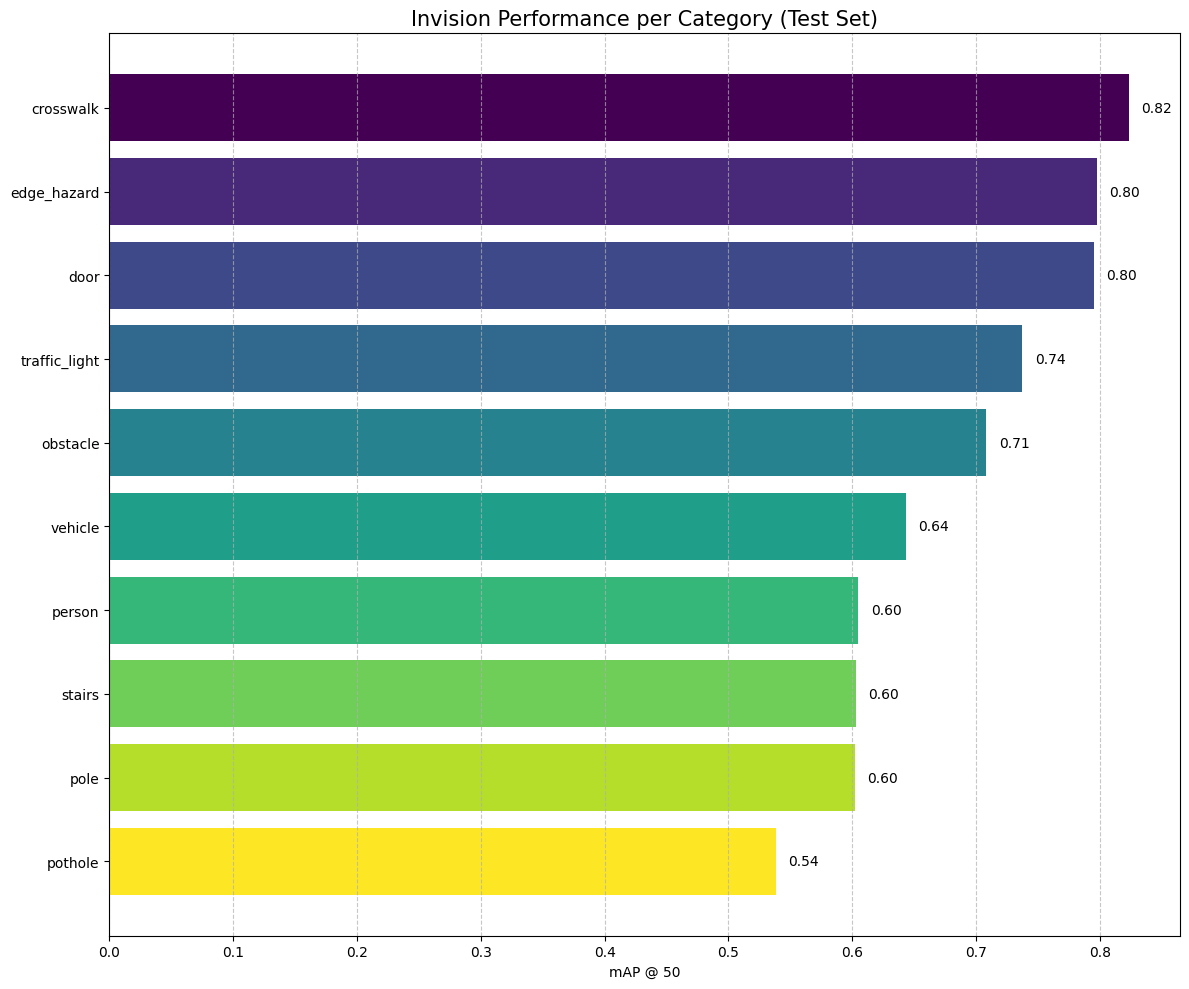

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract class names their respective mAP50
maps_per_class = metrics.box.maps  # This gives the mAP50-95 for each class by default in YOLOv8/v11
# Note: If you prefer to visualize exact mAP50, YOLO saves it in results_test.box.map50

# Create a list of tuples (Name, Value) to sort
data_to_plot = []
for i, mAP in enumerate(metrics.box.ap50): # Using ap50 for mAP@.50
    data_to_plot.append((CLASS_NAMES[i], mAP))

# Sort from highest to lowest for better histogram readability
data_to_plot.sort(key=lambda x: x[1], reverse=True)
labels, values = zip(*data_to_plot)

# Create the plot
plt.figure(figsize=(12, 10))
colors = plt.cm.viridis(np.linspace(0, 1, len(labels))) # Beautiful colors

bars = plt.barh(labels, values, color=colors)
plt.xlabel('mAP @ 50')
plt.title('Invision Performance per Category (Test Set)', fontsize=15)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add the numerical value at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}', va='center', fontsize=10)

plt.gca().invert_yaxis() # Put the best class at the top
plt.tight_layout()
plt.show()

# 5. Security reminder based on your rules:
low_perf_classes = [l for l, v in data_to_plot if v < 0.4]
if low_perf_classes:
    print(f"\n⚠️ SECURITY ALERT:")
    print(f"Classes {low_perf_classes} have performance below 40%.")
    print("Remember that if the model fails in these detections, the system must return -1.")